Problem: There is no vormogenverzeichnis=1 prediction in production. Check what is happening

In [5]:
import pandas as pd
from python_utilities.db_connection import DbConnection

In [6]:
analytics_db = DbConnection("ANALYTICS", "PROD_RDS")

INFO [2026-05-27 12:39:35] - PYTHON_UTILITIES - secret_utilities.py - get_db_secret_config - Credentials for database were read from secret.ini file


In [7]:
query = f"""
SELECT *
FROM llm_attachments_predictions lap
WHERE lap.type = 'aftercourt_classification_vermogenverzeichnis'
AND lap.subtype = 'class_pred'
AND lap.value LIKE "%%'True'%%"
"""

In [8]:
data = analytics_db.sql_to_df(query)

In [9]:
data

,id,created_at,model_name,type,subtype,value,attachment_id


In [10]:
# no true predictions

In [11]:
query = f"""
SELECT *
FROM llm_attachments_predictions lap
WHERE lap.type = 'aftercourt_classification_vermogenverzeichnis'
AND lap.subtype = 'class_pred'
AND lap.value LIKE "%%'False'%%"
LIMIT 3000
"""

In [12]:
data = analytics_db.sql_to_df(query)

In [13]:
data.attachment_id.nunique()

1391

In [14]:
data

,id,created_at,model_name,type,subtype,value,attachment_id
0,9444936,2026-05-22 07:30:34,aftercourt_classification_vermogenverzeichnis,aftercourt_classification_vermogenverzeichnis,class_pred,'False',65291242
1,9444959,2026-05-22 07:30:35,aftercourt_classification_vermogenverzeichnis,aftercourt_classification_vermogenverzeichnis,class_pred,'False',65291255
2,9444979,2026-05-22 07:30:37,aftercourt_classification_vermogenverzeichnis,aftercourt_classification_vermogenverzeichnis,class_pred,'False',65291259
3,9444996,2026-05-22 07:30:38,aftercourt_classification_vermogenverzeichnis,aftercourt_classification_vermogenverzeichnis,class_pred,'False',65291184
4,9445013,2026-05-22 07:30:39,aftercourt_classification_vermogenverzeichnis,aftercourt_classification_vermogenverzeichnis,class_pred,'False',65291246
...,...,...,...,...,...,...,...
1386,9649309,2026-05-27 10:04:16,aftercourt_classification_vermogenverzeichnis,aftercourt_classification_vermogenverzeichnis,class_pred,'False',65436655
1387,9649338,2026-05-27 10:04:18,aftercourt_classification_vermogenverzeichnis,aftercourt_classification_vermogenverzeichnis,class_pred,'False',65436398
1388,9649350,2026-05-27 10:04:18,aftercourt_classification_vermogenverzeichnis,aftercourt_classification_vermogenverzeichnis,class_pred,'False',65436662
1389,9649375,2026-05-27 10:04:19,aftercourt_classification_vermogenverzeichnis,aftercourt_classification_vermogenverzeichnis,class_pred,'False',65436391


In [15]:
a_ids = data.attachment_id.unique()

In [16]:
query = f"""
SELECT la.*, lap.model_name, lap.type, lap.subtype, lap.value
FROM llm_attachments la
INNER JOIN llm_attachments_predictions lap
ON la.attachment_id = lap.attachment_id
WHERE lap.attachment_id IN {tuple(a_ids)}
"""

In [17]:
data = analytics_db.sql_to_df(query)

In [18]:
data

,id,ticket_uuid,attachment_id,zendesk_id,comment_id,status,file_name,file_extension,status_written_at,created_at,s3_key,s3_bucket,model_name,type,subtype,value
0,3612739,d2a1b1ec-c83a-5278-bb2b-e9d9ccec74f4,65291184,None,None,processed,65291184_Dokumente_40526_22052026_075651-signe...,pdf,2026-05-22 07:30:38,2026-05-22 06:44:00,ocr_source_files/2026-05-22/egvp_id_374877/652...,pair-data-engineering-new,aftercourt_classification_ladung,aftercourt_classification_ladung,aftercourt_type,'ladung_va'
1,3612739,d2a1b1ec-c83a-5278-bb2b-e9d9ccec74f4,65291184,None,None,processed,65291184_Dokumente_40526_22052026_075651-signe...,pdf,2026-05-22 07:30:38,2026-05-22 06:44:00,ocr_source_files/2026-05-22/egvp_id_374877/652...,pair-data-engineering-new,aftercourt_classification_ladung,aftercourt_classification_ladung,class_pred,'False'
2,3612739,d2a1b1ec-c83a-5278-bb2b-e9d9ccec74f4,65291184,None,None,processed,65291184_Dokumente_40526_22052026_075651-signe...,pdf,2026-05-22 07:30:38,2026-05-22 06:44:00,ocr_source_files/2026-05-22/egvp_id_374877/652...,pair-data-engineering-new,aftercourt_classification_ladung,aftercourt_classification_ladung,class_prob,'0.0'
3,3612739,d2a1b1ec-c83a-5278-bb2b-e9d9ccec74f4,65291184,None,None,processed,65291184_Dokumente_40526_22052026_075651-signe...,pdf,2026-05-22 07:30:38,2026-05-22 06:44:00,ocr_source_files/2026-05-22/egvp_id_374877/652...,pair-data-engineering-new,aftercourt_classification_pfub,aftercourt_classification_pfub,aftercourt_type,'pfub_erlass'
4,3612739,d2a1b1ec-c83a-5278-bb2b-e9d9ccec74f4,65291184,None,None,processed,65291184_Dokumente_40526_22052026_075651-signe...,pdf,2026-05-22 07:30:38,2026-05-22 06:44:00,ocr_source_files/2026-05-22/egvp_id_374877/652...,pair-data-engineering-new,aftercourt_classification_pfub,aftercourt_classification_pfub,class_pred,'False'
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25334,3629648,dc7e38de-6399-57ea-b46a-a11e6a39c922,65436696,None,None,processed,65436696_Dokumente_101526_27052026_092939.pdf,pdf,2026-05-27 10:04:12,2026-05-27 08:44:00,ocr_source_files/2026-05-27/egvp_id_377555/654...,pair-data-engineering-new,pfub_erlass_egvp,pfub_erlass_egvp,is_pfub,'False'
25335,3629648,dc7e38de-6399-57ea-b46a-a11e6a39c922,65436696,None,None,processed,65436696_Dokumente_101526_27052026_092939.pdf,pdf,2026-05-27 10:04:12,2026-05-27 08:44:00,ocr_source_files/2026-05-27/egvp_id_377555/654...,pair-data-engineering-new,pfub_erlass_egvp,pfub_erlass_egvp,is_invoice_inside,'True'
25336,3629648,dc7e38de-6399-57ea-b46a-a11e6a39c922,65436696,None,None,processed,65436696_Dokumente_101526_27052026_092939.pdf,pdf,2026-05-27 10:04:12,2026-05-27 08:44:00,ocr_source_files/2026-05-27/egvp_id_377555/654...,pair-data-engineering-new,invoice_detection_egvp,invoice_detection_egvp,is_invoice_inside,'True'
25337,3629648,dc7e38de-6399-57ea-b46a-a11e6a39c922,65436696,None,None,processed,65436696_Dokumente_101526_27052026_092939.pdf,pdf,2026-05-27 10:04:12,2026-05-27 08:44:00,ocr_source_files/2026-05-27/egvp_id_377555/654...,pair-data-engineering-new,invoice_detection_egvp,invoice_detection_egvp,start_page,'1'


In [19]:
import sys
sys.path.insert(0, "/Users/melih.gorgulu/Desktop/Projects/aftercourt_automation")

from utils.prod_utils import pivot_attachment_predictions

In [20]:
data

,id,ticket_uuid,attachment_id,zendesk_id,comment_id,status,file_name,file_extension,status_written_at,created_at,s3_key,s3_bucket,model_name,type,subtype,value
0,3612739,d2a1b1ec-c83a-5278-bb2b-e9d9ccec74f4,65291184,None,None,processed,65291184_Dokumente_40526_22052026_075651-signe...,pdf,2026-05-22 07:30:38,2026-05-22 06:44:00,ocr_source_files/2026-05-22/egvp_id_374877/652...,pair-data-engineering-new,aftercourt_classification_ladung,aftercourt_classification_ladung,aftercourt_type,'ladung_va'
1,3612739,d2a1b1ec-c83a-5278-bb2b-e9d9ccec74f4,65291184,None,None,processed,65291184_Dokumente_40526_22052026_075651-signe...,pdf,2026-05-22 07:30:38,2026-05-22 06:44:00,ocr_source_files/2026-05-22/egvp_id_374877/652...,pair-data-engineering-new,aftercourt_classification_ladung,aftercourt_classification_ladung,class_pred,'False'
2,3612739,d2a1b1ec-c83a-5278-bb2b-e9d9ccec74f4,65291184,None,None,processed,65291184_Dokumente_40526_22052026_075651-signe...,pdf,2026-05-22 07:30:38,2026-05-22 06:44:00,ocr_source_files/2026-05-22/egvp_id_374877/652...,pair-data-engineering-new,aftercourt_classification_ladung,aftercourt_classification_ladung,class_prob,'0.0'
3,3612739,d2a1b1ec-c83a-5278-bb2b-e9d9ccec74f4,65291184,None,None,processed,65291184_Dokumente_40526_22052026_075651-signe...,pdf,2026-05-22 07:30:38,2026-05-22 06:44:00,ocr_source_files/2026-05-22/egvp_id_374877/652...,pair-data-engineering-new,aftercourt_classification_pfub,aftercourt_classification_pfub,aftercourt_type,'pfub_erlass'
4,3612739,d2a1b1ec-c83a-5278-bb2b-e9d9ccec74f4,65291184,None,None,processed,65291184_Dokumente_40526_22052026_075651-signe...,pdf,2026-05-22 07:30:38,2026-05-22 06:44:00,ocr_source_files/2026-05-22/egvp_id_374877/652...,pair-data-engineering-new,aftercourt_classification_pfub,aftercourt_classification_pfub,class_pred,'False'
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25334,3629648,dc7e38de-6399-57ea-b46a-a11e6a39c922,65436696,None,None,processed,65436696_Dokumente_101526_27052026_092939.pdf,pdf,2026-05-27 10:04:12,2026-05-27 08:44:00,ocr_source_files/2026-05-27/egvp_id_377555/654...,pair-data-engineering-new,pfub_erlass_egvp,pfub_erlass_egvp,is_pfub,'False'
25335,3629648,dc7e38de-6399-57ea-b46a-a11e6a39c922,65436696,None,None,processed,65436696_Dokumente_101526_27052026_092939.pdf,pdf,2026-05-27 10:04:12,2026-05-27 08:44:00,ocr_source_files/2026-05-27/egvp_id_377555/654...,pair-data-engineering-new,pfub_erlass_egvp,pfub_erlass_egvp,is_invoice_inside,'True'
25336,3629648,dc7e38de-6399-57ea-b46a-a11e6a39c922,65436696,None,None,processed,65436696_Dokumente_101526_27052026_092939.pdf,pdf,2026-05-27 10:04:12,2026-05-27 08:44:00,ocr_source_files/2026-05-27/egvp_id_377555/654...,pair-data-engineering-new,invoice_detection_egvp,invoice_detection_egvp,is_invoice_inside,'True'
25337,3629648,dc7e38de-6399-57ea-b46a-a11e6a39c922,65436696,None,None,processed,65436696_Dokumente_101526_27052026_092939.pdf,pdf,2026-05-27 10:04:12,2026-05-27 08:44:00,ocr_source_files/2026-05-27/egvp_id_377555/654...,pair-data-engineering-new,invoice_detection_egvp,invoice_detection_egvp,start_page,'1'


In [21]:
data_flat = pivot_attachment_predictions(data)

In [22]:
data_flat

,attachment_id,invoice_detection_egvp_end_page,invoice_detection_egvp_is_invoice_inside,invoice_detection_egvp_start_page,ladung_aftercourt_type,ladung_class_pred,ladung_class_prob,ladung_debtor_name,ladung_judicial_summon_date,ladung_slug,...,pfub_erlass_egvp_is_invoice_inside,pfub_erlass_egvp_is_pfub,pfub_erlass_egvp_slug,pfub_slug,vermogenverzeichnis_aftercourt_type,vermogenverzeichnis_class_pred,vermogenverzeichnis_class_prob,vermogenverzeichnis_end_page,vermogenverzeichnis_is_invoice_inside,vermogenverzeichnis_start_page
0,65291184,2,True,1,ladung_va,False,0.00,none,none,none,...,True,False,none,none,vermogenverzeichnis,False,0.020,2,True,1
1,65291242,-1,False,-1,ladung_va,False,0.00,none,none,none,...,False,True,193011257063,193011257063,vermogenverzeichnis,False,0.030,-1,False,-1
2,65291243,-1,False,-1,ladung_va,False,0.02,none,none,none,...,False,False,none,none,vermogenverzeichnis,False,0.015,-1,False,-1
3,65291246,2,True,1,ladung_va,False,0.24,none,none,none,...,True,False,none,none,vermogenverzeichnis,False,0.030,2,True,1
4,65291250,-1,False,-1,ladung_va,False,0.34,none,none,none,...,False,False,none,none,vermogenverzeichnis,False,0.040,-1,False,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1386,65436683,1,True,1,ladung_va,False,0.09,none,none,none,...,True,False,none,none,vermogenverzeichnis,False,0.030,1,True,1
1387,65436687,-1,False,-1,ladung_va,False,0.08,none,none,none,...,False,False,none,none,vermogenverzeichnis,False,0.015,-1,False,-1
1388,65436690,-1,False,-1,ladung_va,False,0.04,none,none,none,...,False,False,none,none,vermogenverzeichnis,False,0.015,-1,False,-1
1389,65436691,-1,False,-1,ladung_va,False,0.01,none,none,none,...,False,True,110162851403,110162851403,vermogenverzeichnis,False,0.030,-1,False,-1


In [23]:
probs_prod = data_flat.vermogenverzeichnis_class_prob

<Axes: >

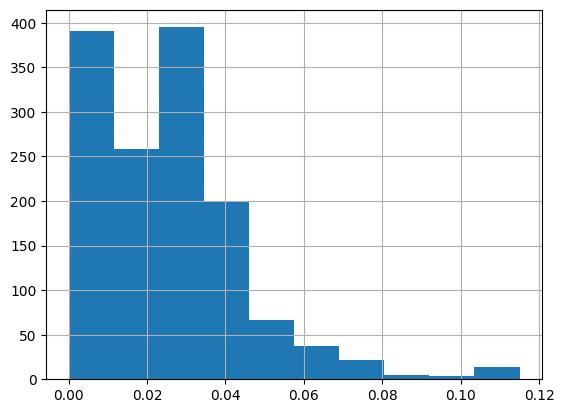

In [24]:
probs_prod.hist()

Check how model is trained. Compare if induvidual steps to train model is equal to production

Model is trained liked this:
1) Cleaned text is used. If cleaned text is null, than it is filled with text field. (This results some fields are not cleaned, which means disperency in the data)
2) Binary target vermögensverzeichnis is taken.
3) Vectorizer "/Users/melih.gorgulu/Desktop/Projects/intent_recognition/notebooks/after-court/models/vectorizers/05-12-2026_tf_idf_vectorizer_v1.dill" loaded
4) so the path is: raw_text -> cleaned_text -> tfidf(05-12-2026_tf_idf_vectorizer_v1.dill) -> Randomforestmodel train

How it is in production:

Path -> raw_text -> cleaned_text (vermogen config, same with above) -> replace with tags -> tf_idf(05-12-2026_tf_idf_vectorizer_v1.dill) -> Model -> prob>50

Problem found: The trained model should be trained on text with tags, since the tf idf vectorizer trained like that. But it is trained on cleaned text, resulting problematic prob predictions

In [25]:
# lets recreate probabilities
# prod: text->cleaned_text(vermogen)->replace_with_tags(vermogen)->tfidf(05-12-2026_tf_idf_vectorizer_v1.dill)->model(15-05-2026_binary_va_rf_classifier_v1.dill)

In [26]:
data_flat.attachment_id.nunique()

1391

In [27]:

import boto3
analytics_db = DbConnection('ANALYTICS', 'PROD_RDS')
# Create session with specific profile
session = boto3.Session(profile_name='739275445236_DataScienceUser')
s3 = session.client('s3')

INFO [2026-05-27 12:40:02] - PYTHON_UTILITIES - secret_utilities.py - get_db_secret_config - Credentials for database were read from secret.ini file
INFO [2026-05-27 12:40:02] - Found credentials in shared credentials file: ~/.aws/credentials


In [28]:
from utils.prod_utils import get_data_by_attachment_id
raw_texts = []

for attachment_id in data_flat.attachment_id.unique():
    fetched_data = get_data_by_attachment_id(attachment_id, analytics_db, s3, pdf_download=False, verbose=False)
    try:
        raw_text = fetched_data.text.iloc[0]
        raw_texts.append(raw_text)
    except Exception as e:
        print(f"Error fetching data for attachment_id {attachment_id}: {e}")
    

In [29]:
from utils.intent_recog_utils import apply_text_cleaning, apply_replace_with_tags

model = 'vermogenverzeichnis' # apply exactly same cleaning and tag replacement as in prod for vermogenverzeichnis

cleaned_texts = [apply_text_cleaning(text, model=model) for text in raw_texts]
text_w_tags = [apply_replace_with_tags(text, model=model) for text in cleaned_texts]

In [30]:
print(len(raw_texts), len(cleaned_texts), len(text_w_tags))

1391 1391 1391


In [31]:
# this happened in prod:
import dill


VEC_PATH = "/Users/melih.gorgulu/Desktop/Projects/aftercourt_automation/models/vectorizers/05-12-2026_tf_idf_vectorizer_v1.dill"
VE_MODEL_PATH = "/Users/melih.gorgulu/Desktop/Projects/aftercourt_automation/models/classification/15-05-2026_binary_va_rf_classifier_v1.dill"

# load models

with open(VEC_PATH, "rb") as f:
    vectorizer = dill.load(f)

with open(VE_MODEL_PATH, "rb") as f:
    ve_model = dill.load(f)


In [32]:
# apply predict proba to text_w_tags to get probabilities and compare with prod probabilities
X = vectorizer.transform(text_w_tags)
probs_recreated = ve_model.predict_proba(X)[:, 1]

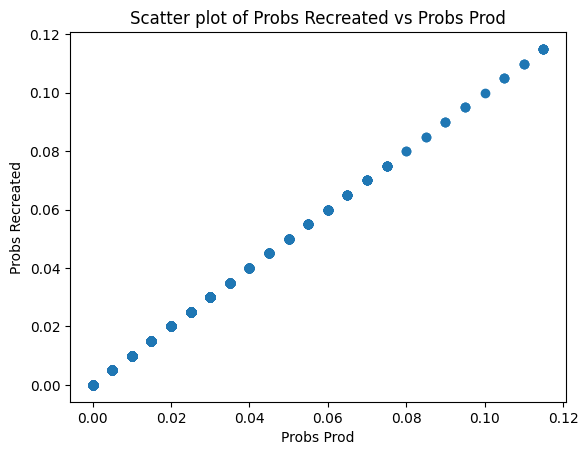

In [33]:
# i would expect probs_recreated == probs_prod

# scatter plot of probs_recreated vs probs_prod
import matplotlib.pyplot as plt
plt.scatter(probs_prod, probs_recreated)
plt.xlabel("Probs Prod")
plt.ylabel("Probs Recreated")
plt.title("Scatter plot of Probs Recreated vs Probs Prod")
plt.show()

In [34]:
# yeah exactly same

In [35]:
all(probs_prod==probs_recreated)

True

In [36]:
# now what whould happen if we calculate probs on clean text
X = vectorizer.transform(cleaned_texts)
probs_fixed = ve_model.predict_proba(X)[:, 1]


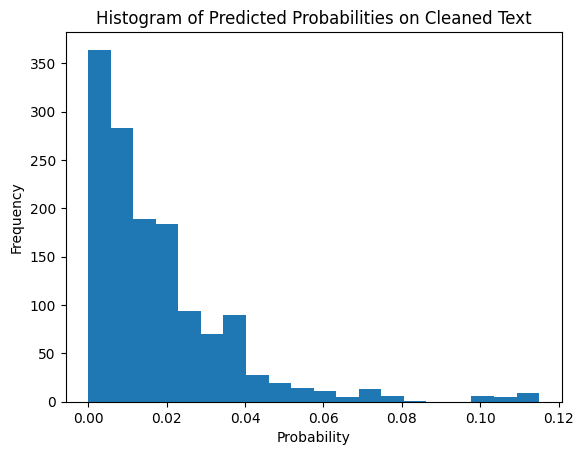

In [44]:
# plots histogram
plt.hist(probs_fixed, bins=20)
plt.xlabel("Probability")
plt.ylabel("Frequency")
plt.title("Histogram of Predicted Probabilities on Cleaned Text")
plt.show()

In [38]:
# ah wait i found the real problem. We use the vectorizer trained on ladung and pfub. We need to train vectorizer on vermogenverzeichnis data to get good predictions.

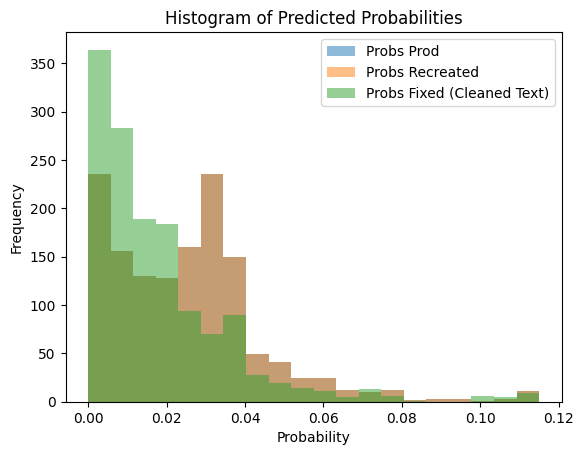

In [45]:
# plot probs_prod, probs_recreated, probs_fixed in the same histogram to compare
plt.hist(probs_prod, bins=20, alpha=0.5, label="Probs Prod")
plt.hist(probs_recreated, bins=20, alpha=0.5, label="Probs Recreated")
plt.hist(probs_fixed, bins=20, alpha=0.5, label="Probs Fixed (Cleaned Text)")
plt.xlabel("Probability")
plt.ylabel("Frequency")
plt.title("Histogram of Predicted Probabilities")
plt.legend()
plt.show()

In [49]:
new_model_path = "/Users/melih.gorgulu/Desktop/Projects/aftercourt_automation/models/classification/vermogensverzeichnis_rf_classifier.dill"
new_vectorizer_path  = "/Users/melih.gorgulu/Desktop/Projects/aftercourt_automation/models/vectorizers/vermogensverzeichnis_vectorizer.dill"

In [50]:
# load
with open(new_vectorizer_path, "rb") as f:
    new_vectorizer = dill.load(f)
with open(new_model_path, "rb") as f:
    new_ve_model = dill.load(f)

In [51]:
# apply
X = new_vectorizer.transform(text_w_tags)
probs_NEW = new_ve_model.predict_proba(X)[:, 1]

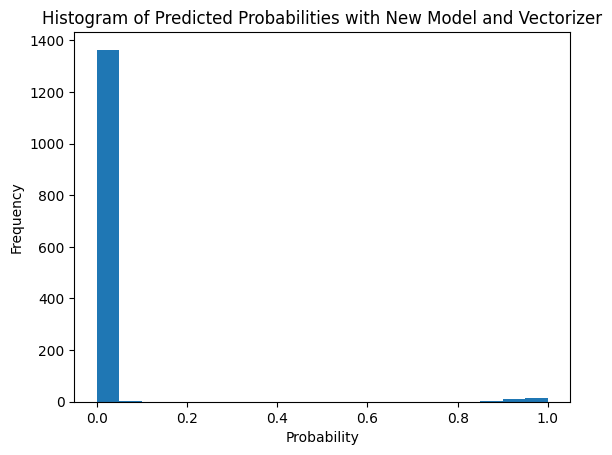

In [52]:
# probs new histogram
plt.hist(probs_NEW, bins=20)
plt.xlabel("Probability")
plt.ylabel("Frequency")
plt.title("Histogram of Predicted Probabilities with New Model and Vectorizer")
plt.show()

In [53]:
# get probs>0.5
arg_probs_NEW = [i for i, prob in enumerate(probs_NEW) if prob > 0.5]
# get attachment ids of probs>0.5
attachment_ids_probs_NEW = data_flat.attachment_id.iloc[arg_probs_NEW]

In [54]:
attachment_ids_probs_NEW

53      65295824
150     65300651
289     65309825
304     65309928
405     65312255
433     65312356
466     65313896
665     65387461
783     65402094
806     65402328
813     65402359
862     65402906
883     65406009
896     65406077
906     65406316
953     65409349
1090    65412033
1106    65412077
1162    65413617
1344    65436515
1346    65436519
1351    65436540
1358    65436563
1372    65436623
Name: attachment_id, dtype: object

In [56]:
# fetch data of these attachment ids to see if they are really false positives or not
ids = attachment_ids_probs_NEW.tolist()

for a_id in ids:
    fetched_data = get_data_by_attachment_id(a_id, analytics_db, s3, pdf_download=True, verbose=True, pdf_download_dir='/Users/melih.gorgulu/Desktop/Projects/aftercourt_automation/assets/pdfs/tmp/sil')
    


📎 ATTACHMENT SUMMARY
Attachment ID:   65295824
File Name:       65295824_Vermoegensverzeichnis_zu_DRII-162924.pdf

│ 📄 Document S3:
│    s3://pair-data-engineering-new/ocr_source_files/2026-05-22/egvp_id_375163/65295824_Vermoegensverzeichnis_zu_DRII-162924.pdf
│
│ 📝 Textract Output:
│    s3://pair-data-engineering-new/ocr_prepared_output/8d2465c2de34dbc572972b91f7aa0d70a1fbd436c54a4030c5922edcc487db64.json
│
│ 📊 Text Length:  9811 characters
│
│ 📥 PDF Downloaded: /Users/melih.gorgulu/Desktop/Projects/aftercourt_automation/assets/pdfs/tmp/sil/65295824.pdf
│
│ 🤖 PREDICTIONS:
│    ⚠️  NOT LADUNG OR PFUB! 
│    Prob Ladung: '0.0'
│    Prob Pfub:   '0.01'
└──────────────────────────────────────────────────────────────────────────────────────────────────


📎 ATTACHMENT SUMMARY
Attachment ID:   65300651
File Name:       65300651_VV_134825-signed.pdf

│ 📄 Document S3:
│    s3://pair-data-engineering-new/ocr_source_files/2026-05-22/egvp_id_375652/65300651_VV_134825-signed.pdf
│
│ 📝 Textract Ou

In [58]:
# filter data flat by attachment_ids_probs_NEW
check = data_flat[data_flat.attachment_id.isin(attachment_ids_probs_NEW)]

In [59]:
check

,attachment_id,invoice_detection_egvp_end_page,invoice_detection_egvp_is_invoice_inside,invoice_detection_egvp_start_page,ladung_aftercourt_type,ladung_class_pred,ladung_class_prob,ladung_debtor_name,ladung_judicial_summon_date,ladung_slug,...,pfub_erlass_egvp_is_invoice_inside,pfub_erlass_egvp_is_pfub,pfub_erlass_egvp_slug,pfub_slug,vermogenverzeichnis_aftercourt_type,vermogenverzeichnis_class_pred,vermogenverzeichnis_class_prob,vermogenverzeichnis_end_page,vermogenverzeichnis_is_invoice_inside,vermogenverzeichnis_start_page
53,65295824,-1,False,-1,ladung_va,False,0.00,none,none,none,...,False,False,none,none,vermogenverzeichnis,False,0.000,-1,False,-1
150,65300651,-1,False,-1,ladung_va,False,0.00,none,none,none,...,False,False,none,none,vermogenverzeichnis,False,0.000,-1,False,-1
289,65309825,-1,False,-1,ladung_va,False,0.00,none,none,none,...,False,False,none,none,vermogenverzeichnis,False,0.000,-1,False,-1
304,65309928,-1,False,-1,ladung_va,False,0.00,none,none,none,...,False,False,none,none,vermogenverzeichnis,False,0.000,-1,False,-1
405,65312255,-1,False,-1,ladung_va,False,0.01,none,none,none,...,False,False,none,none,vermogenverzeichnis,False,0.000,-1,False,-1
433,65312356,-1,False,-1,ladung_va,False,0.00,none,none,none,...,False,False,none,none,vermogenverzeichnis,False,0.000,-1,False,-1
466,65313896,-1,False,-1,ladung_va,False,0.00,none,none,none,...,False,False,none,none,vermogenverzeichnis,False,0.000,-1,False,-1
665,65387461,-1,False,-1,ladung_va,False,0.00,none,none,none,...,False,False,none,none,vermogenverzeichnis,False,0.000,-1,False,-1
783,65402094,-1,False,-1,ladung_va,False,0.01,none,none,none,...,False,False,none,none,vermogenverzeichnis,False,0.000,-1,False,-1
806,65402328,-1,False,-1,ladung_va,False,0.02,none,none,none,...,False,False,none,none,vermogenverzeichnis,False,0.000,-1,False,-1
